BIOBLACKBOX
Forensic Explainability Engine for Biological Deep Learning

Dataset Information
----------------------------------------------------------------------
Number of sequences : 2400
Sequence length     : 80
Class 0 motif       : LIVMGA
Class 1 motif       : KRPQH

Training samples: 1920
Testing samples : 480

Training Deep Learning Model
----------------------------------------------------------------------
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7947 - loss: 0.4328 - val_accuracy: 1.0000 - val_loss: 0.0084
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 2.3647e-04
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 5.1298e-04 - val_accuracy: 1.0000 - val_loss: 1.2286e-04
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 2.8666e-04 - val_accuracy: 1.0000 - val_loss: 6.8970e-05
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step -

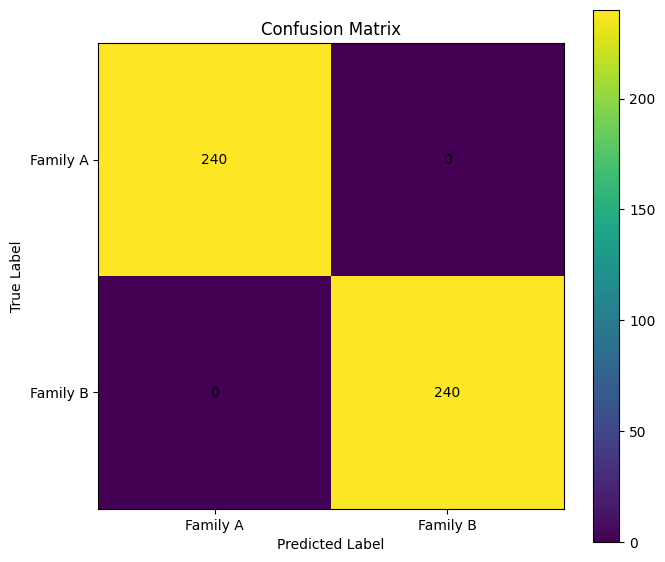


SAMPLE PREDICTION

Protein Sequence:
MYRTSTPFFMTPMPATQCWLCHPEAMEGPRGISVEAHVCQMSHHREIMAMFWKRPKTIDIAQPARLIVMGAWPEWMVGKY

Prediction: Protein Family A
Probability: 0.0001
Confidence: 99.99%
Inserted Motif Position: 66

EXPLANATION ANALYSIS

Top Gradient Positions:
Position 56 | Amino Acid: K | Score: 1.000
Position 57 | Amino Acid: T | Score: 0.915
Position 54 | Amino Acid: R | Score: 0.905
Position 69 | Amino Acid: M | Score: 0.814
Position 55 | Amino Acid: P | Score: 0.789
Position 68 | Amino Acid: V | Score: 0.782
Position 53 | Amino Acid: K | Score: 0.753
Position 67 | Amino Acid: I | Score: 0.690
Position 70 | Amino Acid: G | Score: 0.616
Position 66 | Amino Acid: L | Score: 0.474

Top Occlusion Positions:
Position 68 | Amino Acid: V | Score: 1.000
Position 69 | Amino Acid: M | Score: 0.648
Position 67 | Amino Acid: I | Score: 0.576
Position 70 | Amino Acid: G | Score: 0.230
Position 71 | Amino Acid: A | Score: 0.092
Position 66 | Amino Acid: L | Score: 0.066
Position 54 | Amino Aci

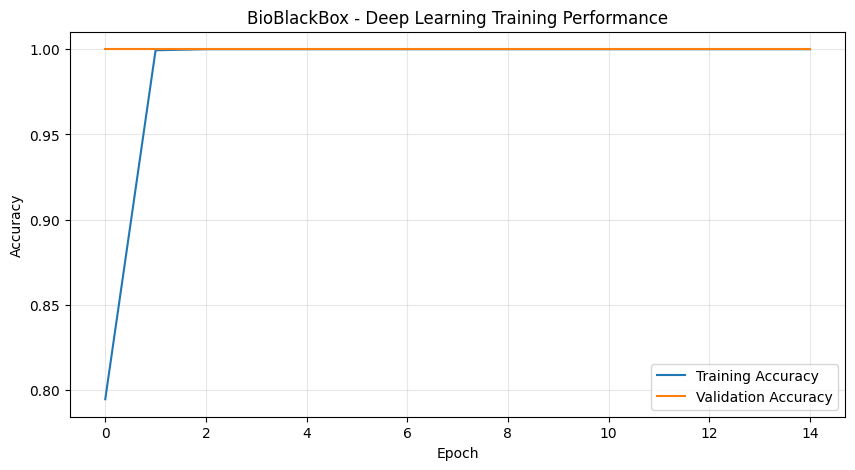

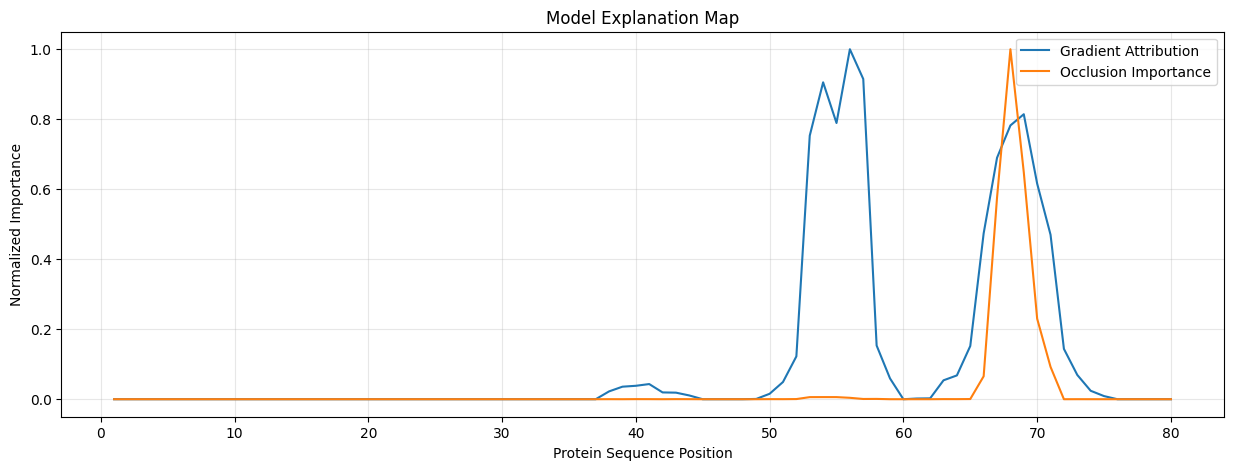

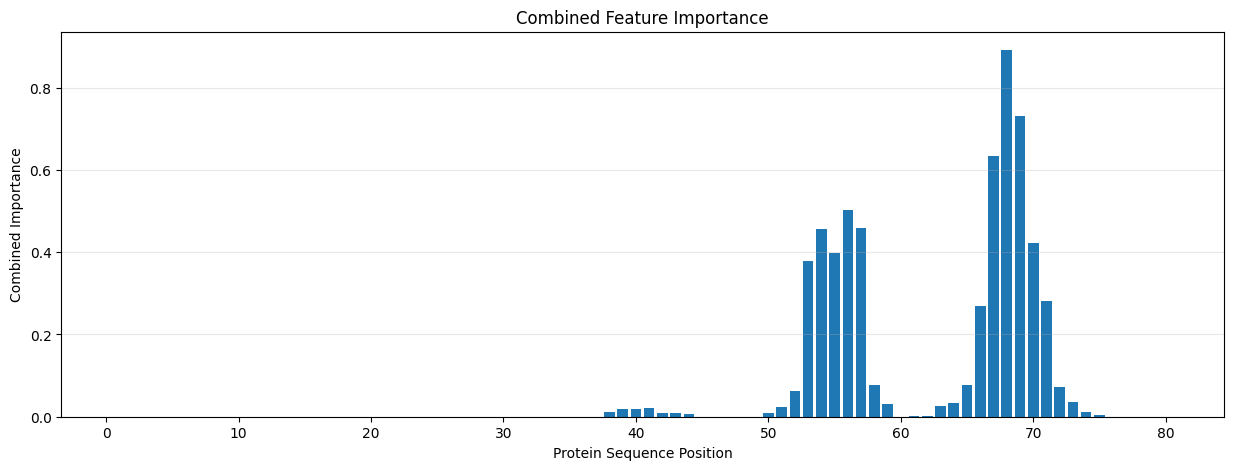

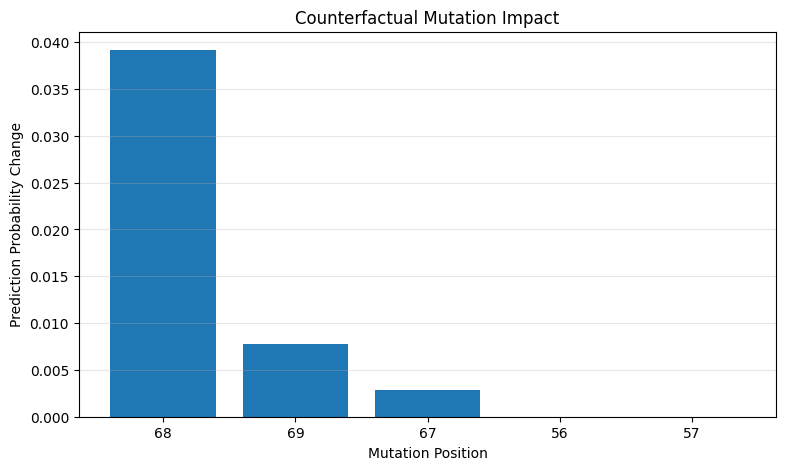

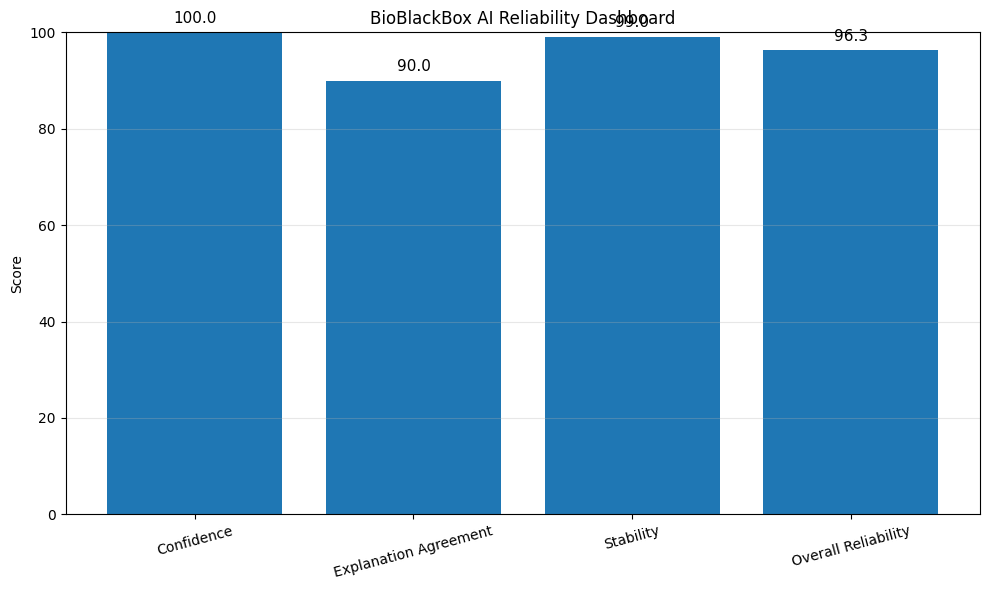

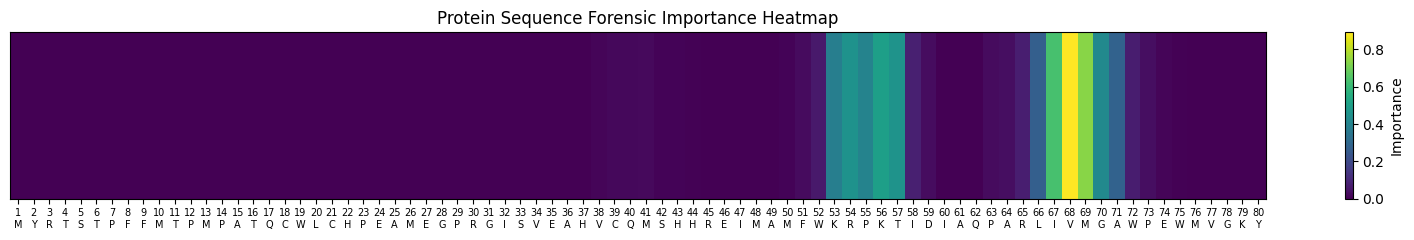


BIOBLACKBOX ANALYSIS COMPLETE

Generated files:

bioblackbox_forensic_report.csv
bioblackbox_counterfactuals.csv
bioblackbox_model.keras

The system performed:

- Deep Learning prediction
- Confidence estimation
- Gradient attribution
- Occlusion analysis
- Explanation agreement
- Counterfactual mutation testing
- Reliability scoring
- AI forensic warnings
- Confusion matrix analysis
- Training performance visualization
- Feature importance visualization
- Counterfactual visualization
- Reliability dashboard
- Protein sequence importance heatmap
- Model export

PROJECT COMPLETE


In [1]:
# ================================================================
# BIOBLACKBOX
# Forensic Explainability Engine for Biological Deep Learning
# ================================================================
# ONE-CELL COMPLETE PROJECT
#
# What this project does:
# 1. Creates a synthetic protein-sequence dataset
# 2. Trains a CNN deep-learning classifier
# 3. Makes a prediction on a new protein sequence
# 4. Calculates model confidence
# 5. Performs gradient-based feature attribution
# 6. Performs occlusion testing
# 7. Compares explanations
# 8. Calculates Explanation Agreement Score
# 9. Performs counterfactual mutation testing
# 10. Generates a forensic AI report
# 11. Produces multiple visualizations
# ================================================================

import sys
import subprocess
import warnings
import random
import os

warnings.filterwarnings("ignore")

# ================================================================
# INSTALL / IMPORT
# ================================================================

try:
    import tensorflow as tf
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "tensorflow"
    ])
    import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

# ================================================================
# REPRODUCIBILITY
# ================================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("BIOBLACKBOX")
print("Forensic Explainability Engine for Biological Deep Learning")
print("=" * 70)

# ================================================================
# 1. CREATE SYNTHETIC PROTEIN DATA
# ================================================================

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

# Artificial biological functional families
MOTIF_A = "LIVMGA"
MOTIF_B = "KRPQH"

SEQ_LENGTH = 80
N_SAMPLES = 2400


def random_sequence(length=SEQ_LENGTH):
    return "".join(
        random.choice(AMINO_ACIDS)
        for _ in range(length)
    )


def insert_motif(sequence, motif):
    sequence = list(sequence)

    position = random.randint(
        5,
        len(sequence) - len(motif) - 5
    )

    sequence[
        position:position + len(motif)
    ] = list(motif)

    return "".join(sequence), position


sequences = []
labels = []
motif_positions = []

for i in range(N_SAMPLES):

    seq = random_sequence()

    if i < N_SAMPLES // 2:

        seq, position = insert_motif(
            seq,
            MOTIF_A
        )

        label = 0

    else:

        seq, position = insert_motif(
            seq,
            MOTIF_B
        )

        label = 1

    sequences.append(seq)
    labels.append(label)
    motif_positions.append(position)


# Shuffle dataset
indices = np.random.permutation(
    N_SAMPLES
)

sequences = np.array(sequences)[indices]
labels = np.array(labels)[indices]

print("\nDataset Information")
print("-" * 70)
print("Number of sequences :", len(sequences))
print("Sequence length     :", SEQ_LENGTH)
print("Class 0 motif       :", MOTIF_A)
print("Class 1 motif       :", MOTIF_B)

# ================================================================
# 2. ENCODE PROTEIN SEQUENCES
# ================================================================

vocab = {
    amino_acid: index + 1
    for index, amino_acid
    in enumerate(AMINO_ACIDS)
}

vocab["PAD"] = 0


def encode_sequence(sequence):
    return [
        vocab[amino_acid]
        for amino_acid in sequence
    ]


X = np.array([
    encode_sequence(sequence)
    for sequence in sequences
])

y = np.array(labels)

# ================================================================
# 3. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# ================================================================
# 4. BUILD DEEP LEARNING MODEL
# ================================================================

model = Sequential([
    Input(shape=(SEQ_LENGTH,)),

    Embedding(
        input_dim=len(vocab),
        output_dim=32
    ),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining Deep Learning Model")
print("-" * 70)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ================================================================
# 5. MODEL EVALUATION
# ================================================================

pred_prob = model.predict(
    X_test,
    verbose=0
).flatten()

pred = (
    pred_prob >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_test,
    pred
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"\nTest Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pred,
        target_names=[
            "Family A",
            "Family B"
        ]
    )
)

# ================================================================
# 6. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Family A", "Family B"]
)

plt.yticks(
    [0, 1],
    ["Family A", "Family B"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# ================================================================
# 7. CREATE CONTROLLED TEST PROTEIN
# ================================================================

sample_sequence = random_sequence()

sample_sequence, true_motif_position = insert_motif(
    sample_sequence,
    MOTIF_A
)

sample_encoded = np.array([
    encode_sequence(sample_sequence)
])

probability = float(
    model.predict(
        sample_encoded,
        verbose=0
    )[0][0]
)

predicted_class = int(
    probability >= 0.5
)

class_name = {
    0: "Protein Family A",
    1: "Protein Family B"
}

confidence = (
    probability
    if predicted_class == 1
    else 1 - probability
)

print("\n" + "=" * 70)
print("SAMPLE PREDICTION")
print("=" * 70)

print("\nProtein Sequence:")
print(sample_sequence)

print(
    "\nPrediction:",
    class_name[predicted_class]
)

print(
    f"Probability: {probability:.4f}"
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

print(
    f"Inserted Motif Position: "
    f"{true_motif_position + 1}"
)

# ================================================================
# 8. GRADIENT-BASED FEATURE ATTRIBUTION
# ================================================================

input_tensor = tf.convert_to_tensor(
    sample_encoded,
    dtype=tf.int32
)

with tf.GradientTape() as tape:

    embedding_output = model.layers[0](
        input_tensor
    )

    tape.watch(
        embedding_output
    )

    x = embedding_output

    for layer in model.layers[1:]:

        x = layer(x)

    output = x[:, 0]

gradients = tape.gradient(
    output,
    embedding_output
)

gradient_scores = np.linalg.norm(
    gradients.numpy()[0],
    axis=1
)

gradient_scores = (
    gradient_scores /
    (gradient_scores.max() + 1e-8)
)

# ================================================================
# 9. OCCLUSION EXPLANATION
# ================================================================

original_probability = probability

occlusion_scores = []

for position in range(SEQ_LENGTH):

    modified = sample_encoded.copy()

    # Replace amino acid with padding
    modified[0, position] = 0

    modified_probability = float(
        model.predict(
            modified,
            verbose=0
        )[0][0]
    )

    impact = abs(
        original_probability -
        modified_probability
    )

    occlusion_scores.append(
        impact
    )

occlusion_scores = np.array(
    occlusion_scores
)

occlusion_scores = (
    occlusion_scores /
    (occlusion_scores.max() + 1e-8)
)

# ================================================================
# 10. EXPLANATION AGREEMENT
# ================================================================

TOP_K = 10

gradient_top = np.argsort(
    gradient_scores
)[-TOP_K:][::-1]

occlusion_top = np.argsort(
    occlusion_scores
)[-TOP_K:][::-1]

gradient_set = set(
    gradient_top
)

occlusion_set = set(
    occlusion_top
)

intersection = (
    gradient_set
    .intersection(
        occlusion_set
    )
)

agreement_score = (
    len(intersection)
    / TOP_K
) * 100

# ================================================================
# 11. EXPLANATION FUSION
# ================================================================

combined_scores = (
    0.5 * gradient_scores
    +
    0.5 * occlusion_scores
)

combined_top = np.argsort(
    combined_scores
)[-10:][::-1]

print("\n" + "=" * 70)
print("EXPLANATION ANALYSIS")
print("=" * 70)

print("\nTop Gradient Positions:")

for position in gradient_top:

    print(
        f"Position {position + 1:02d} | "
        f"Amino Acid: {sample_sequence[position]} | "
        f"Score: {gradient_scores[position]:.3f}"
    )

print("\nTop Occlusion Positions:")

for position in occlusion_top:

    print(
        f"Position {position + 1:02d} | "
        f"Amino Acid: {sample_sequence[position]} | "
        f"Score: {occlusion_scores[position]:.3f}"
    )

print(
    f"\nExplanation Agreement Score: "
    f"{agreement_score:.1f}%"
)

# ================================================================
# 12. COUNTERFACTUAL MUTATION TESTING
# ================================================================

print("\n" + "=" * 70)
print("COUNTERFACTUAL MUTATION ANALYSIS")
print("=" * 70)

mutation_results = []

for position in combined_top[:5]:

    original_aa = (
        sample_sequence[position]
    )

    alternatives = [
        amino_acid
        for amino_acid in AMINO_ACIDS
        if amino_acid != original_aa
    ]

    mutated_aa = random.choice(
        alternatives
    )

    mutated_sequence = list(
        sample_sequence
    )

    mutated_sequence[position] = (
        mutated_aa
    )

    mutated_sequence = "".join(
        mutated_sequence
    )

    mutated_encoded = np.array([
        encode_sequence(
            mutated_sequence
        )
    ])

    mutated_probability = float(
        model.predict(
            mutated_encoded,
            verbose=0
        )[0][0]
    )

    mutated_class = int(
        mutated_probability >= 0.5
    )

    probability_change = abs(
        original_probability
        -
        mutated_probability
    )

    mutation_results.append({
        "Position": position + 1,
        "Original": original_aa,
        "Mutation": mutated_aa,
        "Original Probability": original_probability,
        "Mutated Probability": mutated_probability,
        "Probability Change": probability_change,
        "Class Changed":
            predicted_class != mutated_class
    })

mutation_df = pd.DataFrame(
    mutation_results
)

print(
    mutation_df.to_string(
        index=False
    )
)

# ================================================================
# 13. RELIABILITY SCORE
# ================================================================

confidence_score = (
    confidence * 100
)

explanation_score = (
    agreement_score
)

if len(mutation_df) > 0:

    average_mutation_change = (
        mutation_df[
            "Probability Change"
        ].mean()
    )

else:

    average_mutation_change = 0


stability_score = max(
    0,
    100 -
    average_mutation_change * 100
)

reliability_score = (
    0.45 * confidence_score
    +
    0.35 * explanation_score
    +
    0.20 * stability_score
)

reliability_score = min(
    100,
    max(
        0,
        reliability_score
    )
)

# ================================================================
# 14. RISK LEVEL
# ================================================================

if reliability_score >= 80:

    risk_level = "LOW RISK"

elif reliability_score >= 60:

    risk_level = "MODERATE RISK"

else:

    risk_level = "HIGH RISK"

# ================================================================
# 15. FORENSIC WARNINGS
# ================================================================

warnings_list = []

if confidence_score < 75:

    warnings_list.append(
        "Model confidence is relatively low."
    )

if agreement_score < 50:

    warnings_list.append(
        "Gradient and occlusion explanations disagree."
    )

if average_mutation_change > 0.15:

    warnings_list.append(
        "Prediction is highly sensitive to small mutations."
    )

if len(warnings_list) == 0:

    warnings_list.append(
        "No major forensic warning detected."
    )

# ================================================================
# 16. FINAL FORENSIC REPORT
# ================================================================

print("\n\n")
print("=" * 70)
print("BIOBLACKBOX - AI FORENSIC REPORT")
print("=" * 70)

print(
    f"""
Prediction:
    {class_name[predicted_class]}

Model Probability:
    {probability:.4f}

Model Confidence:
    {confidence_score:.2f}%

Explanation Agreement:
    {agreement_score:.2f}%

Prediction Stability:
    {stability_score:.2f}%

Overall AI Reliability:
    {reliability_score:.2f}/100

Risk Level:
    {risk_level}
"""
)

print("FORENSIC FINDINGS:")

for warning in warnings_list:

    print(
        " -",
        warning
    )

print(
    "\nMost Important Sequence Positions:"
)

for position in combined_top:

    print(
        f" - Position {position + 1}: "
        f"{sample_sequence[position]} "
        f"(Score={combined_scores[position]:.3f})"
    )

# ================================================================
# 17. VISUALIZATION - TRAINING CURVES
# ================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "BioBlackBox - Deep Learning Training Performance"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ================================================================
# 18. VISUALIZATION - EXPLANATION MAP
# ================================================================

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    gradient_scores,
    label="Gradient Attribution"
)

plt.plot(
    range(1, SEQ_LENGTH + 1),
    occlusion_scores,
    label="Occlusion Importance"
)

plt.xlabel(
    "Protein Sequence Position"
)

plt.ylabel(
    "Normalized Importance"
)

plt.title(
    "Model Explanation Map"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ================================================================
# 19. VISUALIZATION - COMBINED IMPORTANCE
# ================================================================

plt.figure(
    figsize=(15, 5)
)

plt.bar(
    range(1, SEQ_LENGTH + 1),
    combined_scores
)

plt.xlabel(
    "Protein Sequence Position"
)

plt.ylabel(
    "Combined Importance"
)

plt.title(
    "Combined Feature Importance"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# ================================================================
# 20. VISUALIZATION - COUNTERFACTUAL MUTATIONS
# ================================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    mutation_df["Position"].astype(str),
    mutation_df["Probability Change"]
)

plt.xlabel(
    "Mutation Position"
)

plt.ylabel(
    "Prediction Probability Change"
)

plt.title(
    "Counterfactual Mutation Impact"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# ================================================================
# 21. VISUALIZATION - RELIABILITY DASHBOARD
# ================================================================

metrics = {
    "Confidence": confidence_score,
    "Explanation Agreement": explanation_score,
    "Stability": stability_score,
    "Overall Reliability": reliability_score
}

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(
    0,
    100
)

plt.ylabel(
    "Score"
)

plt.title(
    "BioBlackBox AI Reliability Dashboard"
)

for bar, value in zip(
    bars,
    metrics.values()
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        value + 2,
        f"{value:.1f}",
        ha="center",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

# ================================================================
# 22. SEQUENCE IMPORTANCE HEATMAP
# ================================================================

plt.figure(
    figsize=(16, 2.5)
)

plt.imshow(
    combined_scores.reshape(
        1,
        -1
    ),
    aspect="auto"
)

plt.colorbar(
    label="Importance"
)

plt.xticks(
    range(SEQ_LENGTH),
    [
        f"{i + 1}\n{sample_sequence[i]}"
        for i in range(SEQ_LENGTH)
    ],
    fontsize=7
)

plt.yticks([])

plt.title(
    "Protein Sequence Forensic Importance Heatmap"
)

plt.tight_layout()

plt.show()

# ================================================================
# 23. EXPORT FORENSIC REPORT
# ================================================================

report = {
    "Prediction":
        class_name[predicted_class],

    "Probability":
        probability,

    "Confidence":
        confidence_score,

    "Explanation Agreement":
        agreement_score,

    "Stability":
        stability_score,

    "Reliability":
        reliability_score,

    "Risk Level":
        risk_level
}

report_df = pd.DataFrame(
    [report]
)

report_df.to_csv(
    "bioblackbox_forensic_report.csv",
    index=False
)

mutation_df.to_csv(
    "bioblackbox_counterfactuals.csv",
    index=False
)

# ================================================================
# 24. SAVE MODEL
# ================================================================

model.save(
    "bioblackbox_model.keras"
)

# ================================================================
# 25. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 70)
print("BIOBLACKBOX ANALYSIS COMPLETE")
print("=" * 70)

print(
    """
Generated files:

bioblackbox_forensic_report.csv
bioblackbox_counterfactuals.csv
bioblackbox_model.keras

The system performed:

- Deep Learning prediction
- Confidence estimation
- Gradient attribution
- Occlusion analysis
- Explanation agreement
- Counterfactual mutation testing
- Reliability scoring
- AI forensic warnings
- Confusion matrix analysis
- Training performance visualization
- Feature importance visualization
- Counterfactual visualization
- Reliability dashboard
- Protein sequence importance heatmap
- Model export
"""
)

print("=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)